In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [168]:
df = pd.read_csv("..//datasets/CLF/vitamin.csv")

In [169]:
df.head()

,...
0,...
1,...
2,...
3,...
4,...


In [170]:
df.shape

(4000, 34)

In [171]:
df.columns

Index(['age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption',
       'exercise_level', 'diet_type', 'sun_exposure', 'income_level',
       'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda',
       'vitamin_d_percent_rda', 'vitamin_e_percent_rda',
       'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda',
       'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml',
       'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count',
       'symptoms_list', 'has_night_blindness', 'has_fatigue',
       'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness',
       'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin',
       'disease_diagnosis', 'has_multiple_deficiencies'],
      dtype='object')

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        4000 non-null   int64  
 1   gender                     4000 non-null   object 
 2   bmi                        4000 non-null   float64
 3   smoking_status             4000 non-null   object 
 4   alcohol_consumption        2722 non-null   object 
 5   exercise_level             4000 non-null   object 
 6   diet_type                  4000 non-null   object 
 7   sun_exposure               4000 non-null   object 
 8   income_level               4000 non-null   object 
 9   latitude_region            4000 non-null   object 
 10  vitamin_a_percent_rda      4000 non-null   float64
 11  vitamin_c_percent_rda      4000 non-null   float64
 12  vitamin_d_percent_rda      4000 non-null   float64
 13  vitamin_e_percent_rda      4000 non-null   float

In [173]:
df.describe()

,...
count,...
mean,...
std,...
min,...
25%,...
50%,...
75%,...
max,...


In [174]:
df.duplicated().sum()

np.int64(0)

In [175]:
df.isnull().sum()

age                             0
gender                          0
bmi                             0
smoking_status                  0
alcohol_consumption          1278
exercise_level                  0
diet_type                       0
sun_exposure                    0
income_level                    0
latitude_region                 0
vitamin_a_percent_rda           0
vitamin_c_percent_rda           0
vitamin_d_percent_rda           0
vitamin_e_percent_rda           0
vitamin_b12_percent_rda         0
folate_percent_rda              0
calcium_percent_rda             0
iron_percent_rda                0
hemoglobin_g_dl                 0
serum_vitamin_d_ng_ml           0
serum_vitamin_b12_pg_ml         0
serum_folate_ng_ml              0
symptoms_count                  0
symptoms_list                1328
has_night_blindness             0
has_fatigue                     0
has_bleeding_gums               0
has_bone_pain                   0
has_muscle_weakness             0
has_numbness_t

In [176]:
df['alcohol_consumption'].unique()

array([nan, 'Moderate', 'Heavy'], dtype=object)

In [177]:
X = df.drop(columns=["disease_diagnosis"])
y = df["disease_diagnosis"]

In [178]:
X['alcohol_consumption'] = X['alcohol_consumption'].fillna("zero")
X['symptoms_list'] = X['symptoms_list'].fillna("asyntomatic")

from sklearn.preprocessing import MultiLabelBinarizer

# 1. Pulisci i sintomi: trasformali in liste
def parse_symptoms(row):
    if pd.isna(row) or row in ['asyntomatic', 'asymptomatic', '']:
        return []  # Nessun sintomo
    return row.split(';')

X['symptoms_parsed'] = X['symptoms_list'].apply(parse_symptoms)

# 2. Applica MultiLabelBinarizer (una colonna per ogni sintomo unico)
mlb = MultiLabelBinarizer()
symptom_encoded = mlb.fit_transform(X['symptoms_parsed'])
symptom_df = pd.DataFrame(
    symptom_encoded, 
    columns=mlb.classes_, 
    index=X.index
)

# 3. Elimina le colonne vecchie e unisci le nuove
X = X.drop(columns=['symptoms_list', 'symptoms_parsed'])
X = pd.concat([X, symptom_df], axis=1)

# (La colonna 'symptoms_count' resta al suo posto, è utile averla)

In [179]:
X.isnull().sum()

age                          0
gender                       0
bmi                          0
smoking_status               0
alcohol_consumption          0
exercise_level               0
diet_type                    0
sun_exposure                 0
income_level                 0
latitude_region              0
vitamin_a_percent_rda        0
vitamin_c_percent_rda        0
vitamin_d_percent_rda        0
vitamin_e_percent_rda        0
vitamin_b12_percent_rda      0
folate_percent_rda           0
calcium_percent_rda          0
iron_percent_rda             0
hemoglobin_g_dl              0
serum_vitamin_d_ng_ml        0
serum_vitamin_b12_pg_ml      0
serum_folate_ng_ml           0
symptoms_count               0
has_night_blindness          0
has_fatigue                  0
has_bleeding_gums            0
has_bone_pain                0
has_muscle_weakness          0
has_numbness_tingling        0
has_memory_problems          0
has_pale_skin                0
has_multiple_deficiencies    0
bleeding

In [180]:
colonne_binarie = [col for col in X.columns if X[col].nunique() == 2]
print("Colonne binarie:", colonne_binarie)

Colonne binarie: ['gender', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'has_multiple_deficiencies', 'bleeding_gums', 'bone_pain', 'dry_skin', 'fatigue', 'memory_problems', 'muscle_weakness', 'night_blindness', 'numbness_tingling', 'pale_skin']


In [181]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [182]:
le = LabelEncoder()
for a in colonne_binarie:
    X[a] = le.fit_transform(X[a])



In [183]:
X.head()

,...
0,...
1,...
2,...
3,...
4,...


In [184]:
lista = ['smoking_status','exercise_level','sun_exposure','income_level','latitude_region']
for l in lista:
    print(X[l].unique())

['Former' 'Never' 'Current']
['Active' 'Light' 'Moderate' 'Sedentary']
['High' 'Low' 'Moderate']
['High' 'Low' 'Middle']
['Mid' 'Low' 'High']


In [185]:
ordine_fumo = ["Never", "Former", "Current"]
ordine_attivita = ["Sedentary", "Light", "Moderate", "Active"]
ordine_livello_1 = ["Low", "Moderate", "High"]
ordine_livello_2 = ["Low", "Middle", "High"]
ordine_livello_3 = ["Low", "Mid", "High"]

categorie_ordinate = [
    ordine_fumo,
    ordine_attivita,
    ordine_livello_1,
    ordine_livello_2,
    ordine_livello_3,
]

ordinal_encoder = OrdinalEncoder(categories=categorie_ordinate)
X[lista] = ordinal_encoder.fit_transform(X[lista])

In [186]:
y = le.fit_transform(y)

In [187]:
y

array([1, 3, 1, ..., 0, 0, 0], shape=(4000,))

In [188]:
X = pd.get_dummies(X, dtype=int)

In [189]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [190]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100, stratify=y)

In [191]:
from sklearn.preprocessing import StandardScaler

In [192]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [193]:
from sklearn.decomposition import PCA

In [194]:
def plot_pca(X_pca, y_train):
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.prism, edgecolor='k', alpha=0.7)
    plt.show()

In [195]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
print(X_train.shape, X_pca.shape)

(3200, 46) (3200, 2)


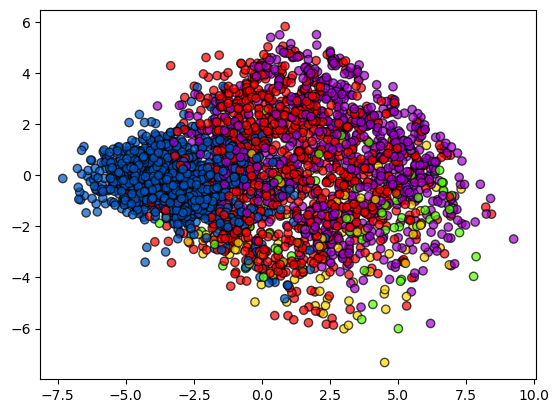

In [196]:
plot_pca(X_pca,y_train)

In [197]:
X_train_pure, X_val, y_train_pure, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_train
)

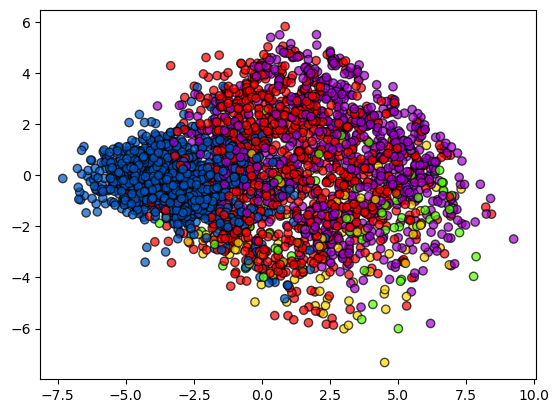

In [198]:
pca = PCA(n_components=2)
pca.fit(X_train)
X_pca = pca.transform(X_train)
plot_pca(X_pca, y_train)

In [199]:
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.neural_network import MLPClassifier
resamplers = {
    "1. Baseline (Nessun Resampling, solo Pesi)": None,
    "2. SMOTE Classico": SMOTE(random_state=42),
    "3. Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "4. SMOTE-Tomek (Ibrido)": SMOTETomek(random_state=42),
    "5. SMOTENN": SMOTEENN(random_state = 42)
}


base_model = MLPClassifier(random_state=42)

print("=== BENCHMARK VELOCE TECNICHE DI BILANCIAMENTO ===\n")

for nome, resampler in resamplers.items():
    if resampler is None:
        X_tr, y_tr = X_train_pure, y_train_pure
    else:
        X_tr, y_tr = resampler.fit_resample(X_train_pure, y_train_pure)
    
    base_model.fit(X_tr, y_tr)

    y_pred = base_model.predict(X_val)
    
    f1_macro = f1_score(y_val, y_pred, average='macro')
    f1_classi = f1_score(y_val, y_pred, average=None)
    
    print(f"{nome}")
    print(f" -> F1-Macro Globale: {f1_macro:.4f}")
    print(f" -> F1 Classe 2 (Rara): {f1_classi[2]:.4f} | F1 Classe 4 (Rara): {f1_classi[4]:.4f}")
    print("-" * 55)

=== BENCHMARK VELOCE TECNICHE DI BILANCIAMENTO ===

1. Baseline (Nessun Resampling, solo Pesi)
 -> F1-Macro Globale: 0.7954
 -> F1 Classe 2 (Rara): 0.5294 | F1 Classe 4 (Rara): 0.7143
-------------------------------------------------------
2. SMOTE Classico
 -> F1-Macro Globale: 0.7905
 -> F1 Classe 2 (Rara): 0.5405 | F1 Classe 4 (Rara): 0.6667
-------------------------------------------------------
3. Borderline-SMOTE
 -> F1-Macro Globale: 0.7949
 -> F1 Classe 2 (Rara): 0.5128 | F1 Classe 4 (Rara): 0.6897
-------------------------------------------------------
4. SMOTE-Tomek (Ibrido)
 -> F1-Macro Globale: 0.7910
 -> F1 Classe 2 (Rara): 0.5128 | F1 Classe 4 (Rara): 0.7097
-------------------------------------------------------
5. SMOTENN
 -> F1-Macro Globale: 0.7232
 -> F1 Classe 2 (Rara): 0.4667 | F1 Classe 4 (Rara): 0.5532
-------------------------------------------------------


# Pesi Bilanciati

In [200]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

pesi_calcolati = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
dizionario_pesi = dict(enumerate(pesi_calcolati))



# Perceptron

In [201]:
from sklearn.linear_model import Perceptron

In [202]:
clf = Perceptron(tol=1e-3, random_state=0, class_weight=dizionario_pesi)
clf.fit(X_train, y_train)
clf.score(X_train, y_train)

0.8571875

In [203]:
y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

In [204]:
print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()

print('Test Accuracy %s' % accuracy_score(y_test, y_test_pred))
print('Test F1-score %s' % f1_score(y_test, y_test_pred, average=None))

Train Accuracy 0.8571875
Train F1-score [0.85376662 0.9212828  0.63348416 0.83322433 0.57798165]

Test Accuracy 0.8375
Test F1-score [0.82330097 0.91836735 0.63333333 0.82233503 0.3255814 ]


In [205]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       249
           1       0.94      0.89      0.92       302
           2       0.53      0.79      0.63        24
           3       0.86      0.79      0.82       206
           4       0.29      0.37      0.33        19

    accuracy                           0.84       800
   macro avg       0.68      0.74      0.70       800
weighted avg       0.85      0.84      0.84       800



In [206]:
# assicurati di avere il repo in sys.path e di rimuovere i moduli caricati
import sys, os
repo_path = r'C:\Users\david\RuleTree'
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)
for _m in list(sys.modules):
    if _m == 'RuleTree' or _m.startswith('RuleTree.'):
        del sys.modules[_m]

In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=300, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_test_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)




Accuracy 0.9275
F1-score [0.91585127 0.92047377 0.76190476 0.97596154 0.85      ]
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       249
           1       0.94      0.90      0.92       302
           2       0.89      0.67      0.76        24
           3       0.97      0.99      0.98       206
           4       0.81      0.89      0.85        19

    accuracy                           0.93       800
   macro avg       0.90      0.88      0.88       800
weighted avg       0.93      0.93      0.93       800

Fidelity of Trepan to the original model: 0.81125


In [208]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
from RuleTree.stumps.classification.MofNTrepanStumpClassifier import MofNTrepanStumpClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=50, base_stumps=[MofNTrepanStumpClassifier()], random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_test_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)


Accuracy 0.89625
F1-score [0.88976378 0.91900826 0.81632653 0.91089109 0.52941176]
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       249
           1       0.92      0.92      0.92       302
           2       0.80      0.83      0.82        24
           3       0.93      0.89      0.91       206
           4       0.60      0.47      0.53        19

    accuracy                           0.90       800
   macro avg       0.82      0.81      0.81       800
weighted avg       0.90      0.90      0.90       800

Fidelity of Trepan to the original model: 0.84125


# MLP CLASSIFIER

In [209]:
from sklearn.neural_network import MLPClassifier

In [210]:
clf = MLPClassifier(random_state=0)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.9175
F1-score [0.91206544 0.94859038 0.80851064 0.92198582 0.57894737]
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       249
           1       0.95      0.95      0.95       302
           2       0.83      0.79      0.81        24
           3       0.90      0.95      0.92       206
           4       0.58      0.58      0.58        19

    accuracy                           0.92       800
   macro avg       0.84      0.83      0.83       800
weighted avg       0.92      0.92      0.92       800



In [211]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=50, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)


Accuracy 0.9775
F1-score [0.97991968 0.97512438 0.96       0.98305085 0.94444444]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       249
           1       0.98      0.97      0.98       302
           2       0.92      1.00      0.96        24
           3       0.98      0.99      0.98       206
           4       1.00      0.89      0.94        19

    accuracy                           0.98       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.98      0.98      0.98       800

Fidelity of Trepan to the original model: 0.91


In [212]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
from RuleTree.stumps.classification.MofNTrepanStumpClassifier import MofNTrepanStumpClassifier
trepan_clf = TrepanClassifier(estimator = clf, s_min=50, max_depth=8,
base_stumps=[MofNTrepanStumpClassifier()], random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)


Accuracy 0.975
F1-score [0.976      0.97666667 0.93877551 0.97820823 0.94736842]
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       249
           1       0.98      0.97      0.98       302
           2       0.92      0.96      0.94        24
           3       0.98      0.98      0.98       206
           4       0.95      0.95      0.95        19

    accuracy                           0.97       800
   macro avg       0.96      0.97      0.96       800
weighted avg       0.98      0.97      0.98       800

Fidelity of Trepan to the original model: 0.9125


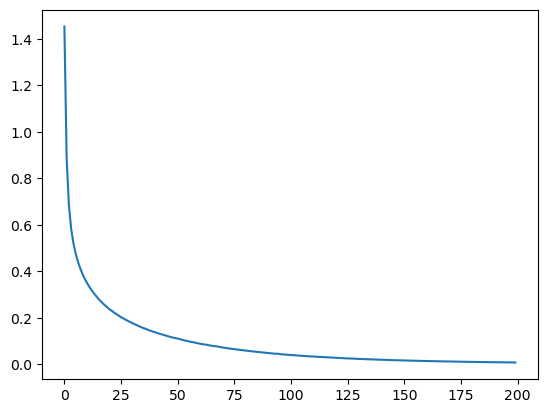

In [213]:
plt.plot(clf.loss_curve_)
plt.show()

In [214]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.89625
F1-score [0.87982833 0.94498382 0.66666667 0.89038031 0.54545455]
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       249
           1       0.92      0.97      0.94       302
           2       1.00      0.50      0.67        24
           3       0.83      0.97      0.89       206
           4       0.64      0.47      0.55        19

    accuracy                           0.90       800
   macro avg       0.87      0.75      0.79       800
weighted avg       0.90      0.90      0.89       800



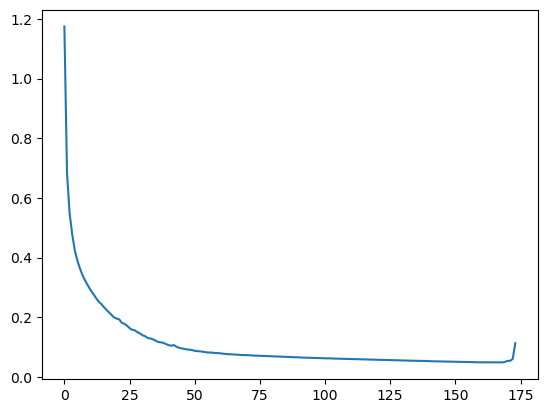

In [215]:
plt.plot(clf.loss_curve_)
plt.show()

In [216]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.91375
F1-score [0.90416667 0.95299838 0.68       0.92601432 0.52941176]
              precision    recall  f1-score   support

           0       0.94      0.87      0.90       249
           1       0.93      0.97      0.95       302
           2       0.65      0.71      0.68        24
           3       0.91      0.94      0.93       206
           4       0.60      0.47      0.53        19

    accuracy                           0.91       800
   macro avg       0.81      0.79      0.80       800
weighted avg       0.91      0.91      0.91       800



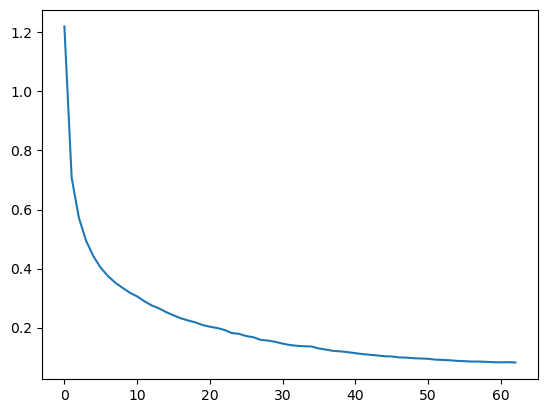

In [217]:
plt.plot(clf.loss_curve_)
plt.show()

In [218]:
from sklearn.model_selection import RandomizedSearchCV

In [219]:
param_list = {
    'hidden_layer_sizes': [(32, ), (16, ), (64, 32,), (32,16)],
    'alpha': [0.1, 0.01, 0.001],
    'activation': ['tanh', 'relu', 'logistic'],
    'solver': ['sgd', 'adam'],
    'early_stopping': [True, False]
}

In [220]:
random_search = RandomizedSearchCV(
    MLPClassifier(random_state=0, max_iter=100),
    param_distributions=param_list,
    n_jobs=-1,
    refit=True,
    scoring = 'f1_macro',
    verbose=2,
)

In [221]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,MLPClassifier...andom_state=0)
,param_distributions,"{'activation': ['tanh', 'relu', ...], 'alpha': [0.1, 0.01, ...], 'early_stopping': [True, False], 'hidden_layer_sizes': [(32,), (16,), ...], ...}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [222]:
print(random_search.best_params_, random_search.best_score_)

{'solver': 'adam', 'hidden_layer_sizes': (64, 32), 'early_stopping': False, 'alpha': 0.1, 'activation': 'tanh'} 0.7884178029348841


In [223]:
clf = MLPClassifier(**random_search.best_params_)

clf.fit(X_train, y_train)
y_train_pred = clf.predict(X_train)
y_pred = clf.predict(X_test)

print('Train Accuracy %s' % accuracy_score(y_train, y_train_pred))
print('Train F1-score %s' % f1_score(y_train, y_train_pred, average=None))
print()
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Train Accuracy 1.0
Train F1-score [1. 1. 1. 1. 1.]

Accuracy 0.90625
F1-score [0.90688259 0.94078947 0.65       0.91252955 0.51428571]
              precision    recall  f1-score   support

           0       0.91      0.90      0.91       249
           1       0.93      0.95      0.94       302
           2       0.81      0.54      0.65        24
           3       0.89      0.94      0.91       206
           4       0.56      0.47      0.51        19

    accuracy                           0.91       800
   macro avg       0.82      0.76      0.78       800
weighted avg       0.90      0.91      0.90       800



# Keras Deep Neural Network

In [224]:
!pip install scikeras

In [225]:
!pip install tensorflow

In [226]:
!pip install keras

In [227]:
from scikeras.wrappers import KerasClassifier
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense

In [228]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [229]:
pesi_calcolati = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
dizionario_pesi = dict(enumerate(pesi_calcolati))

In [230]:
n_classes = 5
def build_model():

    n_feature = X_train.shape[1]
    model = Sequential()
    model.add(Dense(16, input_dim=n_feature, activation='relu'))
    #model.add(Dense(16, activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer="adam", metrics=['accuracy'])
    return model

In [231]:
model1 = build_model()
model1.summary()

ValueError: Insufficient console width to print summary.

In [ ]:
history1 = model1.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val)).history

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5016 - loss: 1.3398 - val_accuracy: 0.6594 - val_loss: 0.9166
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7191 - loss: 0.8112 - val_accuracy: 0.7281 - val_loss: 0.6914
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7652 - loss: 0.6520 - val_accuracy: 0.7563 - val_loss: 0.5944
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7937 - loss: 0.5694 - val_accuracy: 0.7812 - val_loss: 0.5379
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8109 - loss: 0.5169 - val_accuracy: 0.8016 - val_loss: 0.4976
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8281 - loss: 0.4777 - val_accuracy: 0.8000 - val_loss: 0.4669
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8344 - loss: 0.4469 - val_accuracy: 0.8172 - val_loss: 0.4412
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8461 - loss: 0.4199 - val_accuracy: 0.8250 - val_loss:

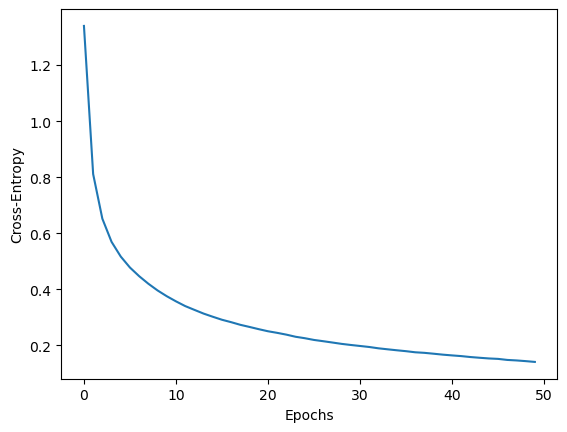

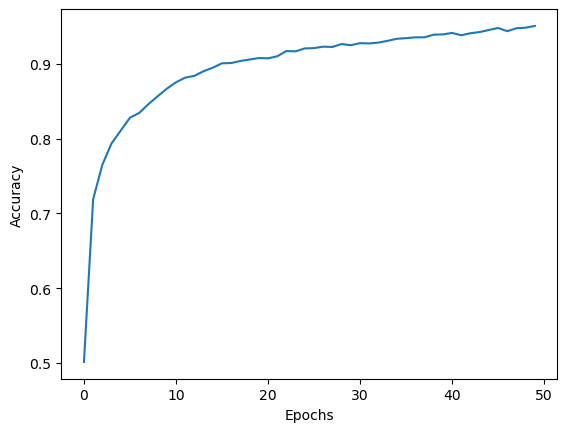

In [ ]:
plt.plot(history1['loss'])
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.show()
plt.plot(history1['accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
test_loss_1, test_acc_1 = model1.evaluate(X_test, y_test)
print('Loss %f, Accuracy %f' % (test_loss_1, test_acc_1))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8938 - loss: 0.2848 
Loss 0.284794, Accuracy 0.893750


In [ ]:
clf = KerasClassifier(build_fn=build_model, class_weight=dizionario_pesi)

In [ ]:
clf.fit(X_train, y_train, epochs=22, validation_data=(X_val, y_val))

Epoch 1/22


c:\Users\david\anaconda3\envs\tf_env\lib\site-packages\scikeras\wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
c:\Users\david\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3051 - loss: 1.9149 - val_accuracy: 0.4609 - val_loss: 1.3048
Epoch 2/22
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4859 - loss: 1.4417 - val_accuracy: 0.5875 - val_loss: 1.0929
Epoch 3/22
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6051 - loss: 1.2176 - val_accuracy: 0.6406 - val_loss: 0.9772
Epoch 4/22
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6633 - loss: 1.0747 - val_accuracy: 0.6969 - val_loss: 0.8796
Epoch 5/22
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7020 - loss: 0.9623 - val_accuracy: 0.7141 - val_loss: 0.8146
Epoch 6/22
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7258 - loss: 0.8566 - val_accuracy: 0.7406 - val_loss: 0.7401
Epoch 7/22
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7477 - loss: 0.7598 - val_accuracy: 0.7641 - val_loss: 0.6992
Epoch 8/22
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7656 - loss: 0.6864 - val_accuracy: 0.7688 - val_loss: 0.6578
Epo

,model,None
,build_fn,<function bui...0013CB234BF40>
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,None


In [ ]:
clf.model_.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │           752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,513 (9.82 KB)

 Trainable params: 837 (3.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,676 (6.55 KB)

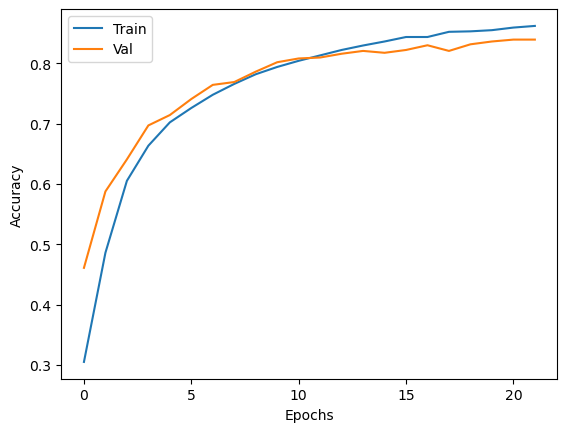

In [ ]:
history = clf.history_
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

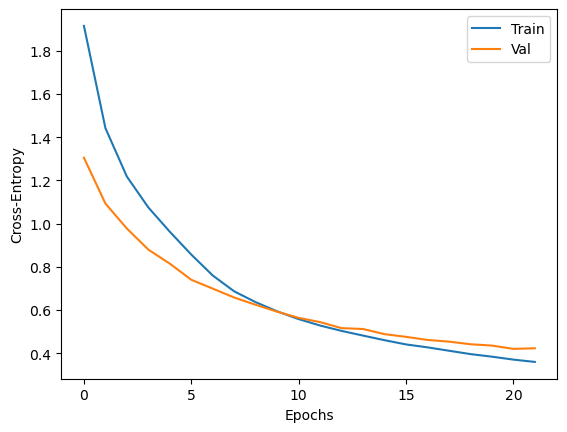

In [ ]:
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

In [ ]:
y_pred = clf.predict(X_test).astype(int)
y_pred_train = clf.predict(X_train).astype(int)
print('Accuracy %s' % accuracy_score(y_train, y_pred_train))
print('F1-score %s' % f1_score(y_train, y_pred_train, average=None))

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.864453125
F1-score [0.85273492 0.93076523 0.58461538 0.87160121 0.61375661]
Accuracy 0.82875
F1-score [0.82589286 0.91156463 0.48101266 0.83412322 0.47619048]
              precision    recall  f1-score   support

           0       0.93      0.74      0.83       249
           1       0.94      0.89      0.91       302
           2       0.35      0.79      0.48        24
           3       0.81      0.85      0.83       206
           4       0.34      0.79      0.48        19

    accuracy                           0.83       800
   macro avg       0.67      0.81      0.71       800
weighted avg       0.87      0.83      0.84       800



In [ ]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, Callback

In [ ]:
import numpy as np
from keras.callbacks import Callback
from sklearn.metrics import f1_score, accuracy_score

class F1CheckpointAndStopping(Callback):
    def __init__(self, validation_data, filepath='best_model.keras',
                 f1_threshold=0.75, acc_threshold=0.85, patience=10):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.filepath = filepath
        self.f1_thresh = f1_threshold
        self.acc_thresh = acc_threshold
        self.patience = patience

        self.best_f1 = -1.0
        self.wait = 0

    def on_epoch_end(self, epoch, logs=None):
        # 1. Predizioni
        y_pred_probs = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(y_pred_probs, axis=1)

        # 2. Metriche
        current_f1 = f1_score(self.y_val, y_pred, average='macro')
        current_acc = accuracy_score(self.y_val, y_pred)

        # 3. Log per tracking (opzionale)
        logs['val_f1_macro'] = current_f1
        print(f"Epoch {epoch+1}: val_f1_macro={current_f1:.4f}, val_acc={current_acc:.4f}")

        # 4. Saver: se la F1-macro migliora, salva il modello
        if current_f1 > self.best_f1:
            self.best_f1 = current_f1
            self.model.save(self.filepath)
            print(f"  -> Nuovo best F1-macro: {self.best_f1:.4f}. Modello salvato.")

        # 5. Stopper: se entrambe le metriche superano le soglie, incrementa la pazienza
        if current_f1 >= self.f1_thresh and current_acc >= self.acc_thresh:
            self.wait += 1
            if self.wait >= self.patience:
                print(f"  -> Early stopping attivato dopo {self.wait} epoche consecutive sopra soglie.")
                self.model.stop_training = True
        else:
            self.wait = 0  # reset se anche una metrica scende sotto soglia

In [ ]:
es = EarlyStopping(monitor='val_loss', mode='min', patience=25, verbose=True, restore_best_weights=True)


f1_stopper_saver = F1CheckpointAndStopping(
    validation_data=(X_val, y_val),
    filepath='best_model_NOREG.keras',
    f1_threshold=0.79,
    acc_threshold=0.85,
    patience=1
)

clf = KerasClassifier(build_model, callbacks=[f1_stopper_saver], class_weight=dizionario_pesi)

In [ ]:
clf.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200)

Epoch 1/200


c:\Users\david\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


48/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1725 - loss: 2.0275  Epoch 1: val_f1_macro=0.3062, val_acc=0.4328
  -> Nuovo best F1-macro: 0.3062. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2703 - loss: 1.7126 - val_accuracy: 0.4328 - val_loss: 1.4046 - val_f1_macro: 0.3062
Epoch 2/200
60/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4742 - loss: 1.2832Epoch 2: val_f1_macro=0.4232, val_acc=0.5547
  -> Nuovo best F1-macro: 0.4232. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5043 - loss: 1.2495 - val_accuracy: 0.5547 - val_loss: 1.0891 - val_f1_macro: 0.4232
Epoch 3/200
76/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5704 - loss: 1.0298Epoch 3: val_f1_macro=0.5066, val_acc=0.6172
  -> Nuovo best F1-macro: 0.5066. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5984 - loss: 1.0124 - val_accuracy: 0.6172 - val_loss: 0.9498 - val_f1_macro: 0.5066
Epoch 4/200
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc

,model,<function bui...0013CB234BF40>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,[<__main__.F1C...0013CC32B0BE0>]


In [ ]:
y_pred = clf.predict(X_test).astype(int)
y_pred_train = clf.predict(X_train).astype(int)

print('Accuracy %s' % accuracy_score(y_train, y_pred_train))
print('F1-score %s' % f1_score(y_train, y_pred_train, average=None))

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.946875
F1-score [0.94239482 0.96087637 0.82539683 0.96       0.84722222]
Accuracy 0.89125
F1-score [0.89787234 0.93979933 0.64516129 0.89952153 0.5       ]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       249
           1       0.95      0.93      0.94       302
           2       0.53      0.83      0.65        24
           3       0.89      0.91      0.90       206
           4       0.39      0.68      0.50        19

    accuracy                           0.89       800
   macro avg       0.74      0.84      0.78       800
weighted avg       0.91      0.89      0.90       800



# L2 Regularization

In [ ]:
from keras.regularizers import l2, l1

def build_L2_model():
    model = Sequential()

    n_feature = X_train.shape[1]
    h_dim=16
    model.add(Dense(h_dim, activation='relu',
                    input_shape=(n_feature,), kernel_regularizer=l2(0.025)))
    #model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
    #model.add(Dense(16, activation='relu', kernel_regularizer=l2(0.01)))
    #model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [ ]:
#f1_saver = F1MacroCheckpoint(validation_data=(X_val, y_val), filepath='best_model_L2.keras')
f1_stopper_saver = F1CheckpointAndStopping(
    validation_data=(X_val, y_val),
    filepath='best_model_L2.keras',
    f1_threshold=0.82,
    acc_threshold=0.83,
    patience=2
)
L2_model = KerasClassifier(build_L2_model, callbacks=[f1_stopper_saver], class_weight=dizionario_pesi)
L2_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200)

Epoch 1/200


c:\Users\david\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


76/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3545 - loss: 2.3300Epoch 1: val_f1_macro=0.3800, val_acc=0.5250
  -> Nuovo best F1-macro: 0.3800. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4238 - loss: 2.0976 - val_accuracy: 0.5250 - val_loss: 1.6545 - val_f1_macro: 0.3800
Epoch 2/200
67/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5410 - loss: 1.7813Epoch 2: val_f1_macro=0.4973, val_acc=0.6359
  -> Nuovo best F1-macro: 0.4973. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5707 - loss: 1.6868 - val_accuracy: 0.6359 - val_loss: 1.4351 - val_f1_macro: 0.4973
Epoch 3/200
75/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6365 - loss: 1.5160Epoch 3: val_f1_macro=0.5832, val_acc=0.7031
  -> Nuovo best F1-macro: 0.5832. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6590 - loss: 1.4406 - val_accuracy: 0.7031 - val_loss: 1.2580 - val_f1_macro: 0.5832
Epoch 4/200
73/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accu

,model,<function bui...0013CC1F18310>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,[<__main__.F1C...0013CC32D3760>]


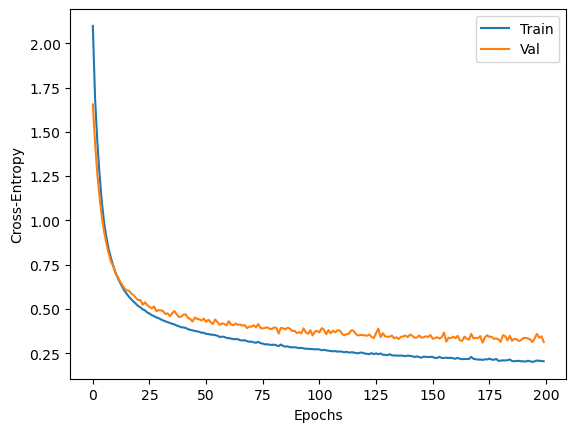

In [ ]:
history = L2_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

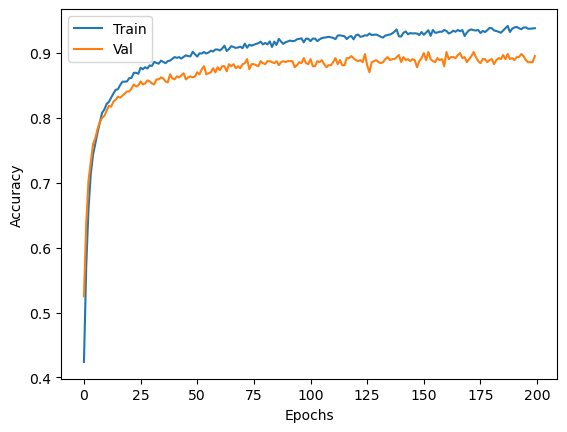

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
y_pred = L2_model.predict(X_test).astype(int)
y_pred_train = L2_model.predict(X_train).astype(int)

print('Accuracy %s' % accuracy_score(y_train, y_pred_train))
print('F1-score %s' % f1_score(y_train, y_pred_train, average=None))

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.941015625
F1-score [0.93341952 0.95579823 0.8342246  0.95665399 0.82432432]
Accuracy 0.90375
F1-score [0.90605428 0.93624161 0.70967742 0.91566265 0.625     ]
              precision    recall  f1-score   support

           0       0.94      0.87      0.91       249
           1       0.95      0.92      0.94       302
           2       0.58      0.92      0.71        24
           3       0.91      0.92      0.92       206
           4       0.52      0.79      0.62        19

    accuracy                           0.90       800
   macro avg       0.78      0.88      0.82       800
weighted avg       0.92      0.90      0.91       800



# Dropout

In [ ]:
from keras.layers import Dropout

def build_DROPOUT_model():
    # define the model
    model = Sequential()

    n_feature = X_train.shape[1]
    h_dim=16
    model.add(Dense(h_dim, activation='relu', input_shape=(n_feature,)))
   # model.add(Dense(16, activation='relu'))
    #model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.25))
    #model.add(Dense(h_dim, activation='relu'))
    #linear activation
    model.add(Dense(n_classes, activation='softmax'))

    #compile the model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [ ]:

f1_stopper_saver = F1CheckpointAndStopping(
    validation_data=(X_val, y_val),
    filepath='best_model_DROPOUT.keras',
    f1_threshold=0.78,
    acc_threshold=0.83,
    patience=1
)
DROPOUT_model = KerasClassifier(build_DROPOUT_model, callbacks=[f1_stopper_saver], class_weight=dizionario_pesi)
DROPOUT_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=250)

c:\Users\david\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/250
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2111 - loss: 2.0416Epoch 1: val_f1_macro=0.3117, val_acc=0.4422
  -> Nuovo best F1-macro: 0.3117. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2680 - loss: 1.8461 - val_accuracy: 0.4422 - val_loss: 1.5110 - val_f1_macro: 0.3117
Epoch 2/250
67/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4170 - loss: 1.4462Epoch 2: val_f1_macro=0.4532, val_acc=0.5844
  -> Nuovo best F1-macro: 0.4532. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4379 - loss: 1.3357 - val_accuracy: 0.5844 - val_loss: 1.1546 - val_f1_macro: 0.4532
Epoch 3/250
69/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5198 - loss: 1.2516Epoch 3: val_f1_macro=0.5356, val_acc=0.6641
  -> Nuovo best F1-macro: 0.5356. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5469 - loss: 1.1497 - val_accuracy: 0.6641 - val_loss: 0.9841 - val_f1_macro: 0.5356
Epoch 4/250
67/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms

,model,<function bui...0013CC4D75360>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'rmsprop'
,loss,None
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,[<__main__.F1C...0013CC5F3BEE0>]


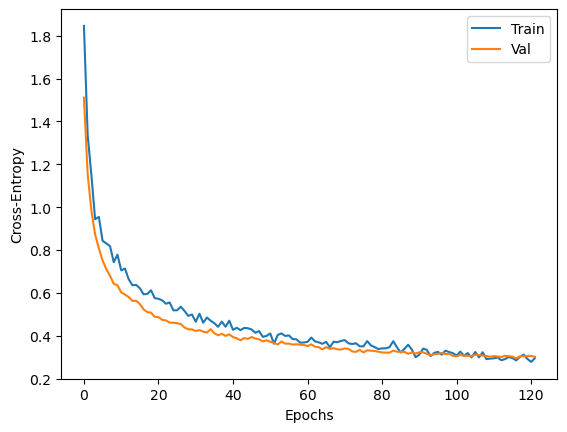

In [ ]:
history = DROPOUT_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

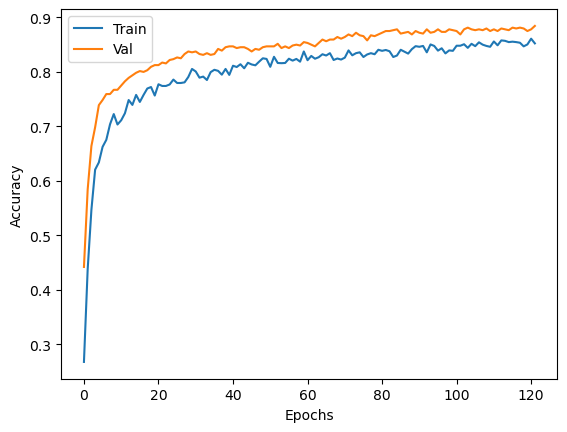

In [ ]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
y_pred = DROPOUT_model.predict(X_test).astype(int)
y_pred_train = DROPOUT_model.predict(X_train).astype(int)

print('Accuracy %s' % accuracy_score(y_train, y_pred_train))
print('F1-score %s' % f1_score(y_train, y_pred_train, average=None))

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy 0.91875
F1-score [0.90412783 0.95173845 0.76470588 0.93272865 0.74390244]
Accuracy 0.8825
F1-score [0.8893617  0.93423272 0.57142857 0.89099526 0.53846154]
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       249
           1       0.95      0.92      0.93       302
           2       0.46      0.75      0.57        24
           3       0.87      0.91      0.89       206
           4       0.42      0.74      0.54        19

    accuracy                           0.88       800
   macro avg       0.73      0.83      0.76       800
weighted avg       0.90      0.88      0.89       800



In [ ]:
# laod best models and test them
from keras.models import load_model

best_NOREG_model = load_model('best_model_NOREG.keras')
best_L2_model = load_model('best_model_L2.keras')
best_DROPOUT_model = load_model('best_model_DROPOUT.keras')


loss_NOREG_train, acc_NOREG_train = best_NOREG_model.evaluate(X_train, y_train)
loss_L2_train, acc_L2_train = best_L2_model.evaluate(X_train, y_train)
loss_DROPOUT_train, acc_DROPOUT_train = best_DROPOUT_model.evaluate(X_train, y_train)

loss_NOREG, acc_NOREG = best_NOREG_model.evaluate(X_test, y_test)
loss_L2, acc_L2 = best_L2_model.evaluate(X_test, y_test)
loss_DROPOUT, acc_DROPOUT = best_DROPOUT_model.evaluate(X_test, y_test)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9469 - loss: 0.1440
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9395 - loss: 0.2449
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9187 - loss: 0.2169
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8913 - loss: 0.3102
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8988 - loss: 0.3261
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8825 - loss: 0.3453


In [ ]:
print('Loss %f, Accuracy %f' % (loss_NOREG, acc_NOREG))
print('Loss %f, Accuracy %f' % (loss_L2, acc_L2))
print('Loss %f, Accuracy %f' % (loss_DROPOUT, acc_DROPOUT))

Loss 0.310166, Accuracy 0.891250
Loss 0.326059, Accuracy 0.898750
Loss 0.345339, Accuracy 0.882500


In [ ]:
def build_model(meta, hidden_layer_sizes, activation,**kwargs):
    n_features_in_ = meta["n_features_in_"]
    n_classes_ = meta["n_classes_"]
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(n_features_in_,)))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(keras.layers.Dense(hidden_layer_size, activation=activation))
    model.add(keras.layers.Dense(n_classes_, activation="softmax"))
    return model

In [ ]:
clf = KerasClassifier(
    model=build_model,
    loss="sparse_categorical_crossentropy",
    verbose=False,
    class_weight=dizionario_pesi
)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:

from keras.layers import Input
def build_ultimate_model(meta, hidden_layer_sizes, activation, dropout_rate=0.2, l2_reg=0.001, **kwargs):
    n_features_in_ = meta["n_features_in_"]
    n_classes_ = meta["n_classes_"]
    
    model = Sequential()
    model.add(Input(shape=(n_features_in_,)))
    
    for hidden_layer_size in hidden_layer_sizes:
        model.add(Dense(
            hidden_layer_size, 
            activation=activation, 
            kernel_regularizer=l2(l2_reg) 
        ))
        model.add(Dropout(dropout_rate))  
        
    model.add(Dense(n_classes_, activation="softmax"))
    
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=kwargs.get('optimizer', 'adam'),
        metrics=['accuracy']
    )
    return model



clf_ultimate = KerasClassifier(
    model=build_ultimate_model,
    class_weight=dizionario_pesi,      
    callbacks=[EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)],              
    validation_split=0.2,
    epochs = 50,
    verbose=0                     
)

params_ultimate = {
    'model__hidden_layer_sizes': [(32, ), (16, ), (32, 16)], 
    'model__activation': ['relu'], 
    'model__dropout_rate': [0.3, 0.35, 0.4],                
    'model__l2_reg': [0.01,0.025, 0.03, 0.035],                    
    'optimizer': ["adam"],
    'optimizer__learning_rate': [0.001, 0.0005],      
    'batch_size': [32,64]                                
}

print("Avvio della Super-Ricerca Iperparametri...")

gs_ultimate = RandomizedSearchCV(
    estimator=clf_ultimate, 
    param_distributions=params_ultimate, 
    scoring='f1_macro',
    verbose=2,             
    n_iter=40,             
    cv=5,
    n_jobs=-1,
    random_state=42
)

gs_ultimate.fit(X_train, y_train)

print("\n=== RISULTATI FINALI ===")
print("Miglior F1-Macro in Cross-Validation:", gs_ultimate.best_score_)
print("Iperparametri vincenti:", gs_ultimate.best_params_)

Avvio della Super-Ricerca Iperparametri...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== RISULTATI FINALI ===
Miglior F1-Macro in Cross-Validation: 0.7308988092167163
Iperparametri vincenti: {'optimizer__learning_rate': 0.001, 'optimizer': 'adam', 'model__l2_reg': 0.01, 'model__hidden_layer_sizes': (32, 16), 'model__dropout_rate': 0.3, 'model__activation': 'relu', 'batch_size': 32}


In [ ]:
y_pred = gs_ultimate.predict(X_test).astype(int)

y_pred_train = gs_ultimate.predict(X_train).astype(int)

print('Accuracy %s' % accuracy_score(y_train, y_pred_train))
print('F1-score %s' % f1_score(y_train, y_pred_train, average=None))

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.876171875
F1-score [0.8785175  0.9352667  0.63865546 0.87548337 0.57711443]
Accuracy 0.87
F1-score [0.87336245 0.94156928 0.59459459 0.8691358  0.5       ]
              precision    recall  f1-score   support

           0       0.96      0.80      0.87       249
           1       0.95      0.93      0.94       302
           2       0.44      0.92      0.59        24
           3       0.88      0.85      0.87       206
           4       0.36      0.84      0.50        19

    accuracy                           0.87       800
   macro avg       0.72      0.87      0.76       800
weighted avg       0.91      0.87      0.88       800



In [ ]:
# Ricostruisci il modello con i migliori parametri
best_params = gs_ultimate.best_params_

# Estrai i parametri del modello (senza prefisso 'model__')
model_params = {k.replace('model__', ''): v for k, v in best_params.items() if k.startswith('model__')}
# Estrai i parametri dell'ottimizzatore (senza prefisso 'optimizer__')
optimizer_params = {k.replace('optimizer__', ''): v for k, v in best_params.items() if k.startswith('optimizer__')}
# Prendi il nome dell'ottimizzatore (se presente, altrimenti default)
optimizer_name = best_params.get('optimizer', 'adam')

# Crea il classificatore finale
final_clf = KerasClassifier(
    model=build_ultimate_model,  
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer_name,
    class_weight=dizionario_pesi,
    callbacks=[F1CheckpointAndStopping(validation_data=(X_val, y_val), filepath='best_model_final.keras')],
    validation_split=0.0,
    verbose=1,
    **model_params  # hidden_layer_sizes, dropout_rate, l2_reg, activation
)

In [ ]:
final_clf.fit(X_train, y_train, epochs=100)

Epoch 1/100
76/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1731 - loss: 2.3911Epoch 1: val_f1_macro=0.4117, val_acc=0.5125
  -> Nuovo best F1-macro: 0.4117. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2313 - loss: 2.2357 - val_f1_macro: 0.4117
Epoch 2/100
73/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3988 - loss: 1.9159Epoch 2: val_f1_macro=0.5140, val_acc=0.6266
  -> Nuovo best F1-macro: 0.5140. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4320 - loss: 1.8542 - val_f1_macro: 0.5140
Epoch 3/100
72/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5061 - loss: 1.7231Epoch 3: val_f1_macro=0.5533, val_acc=0.6672
  -> Nuovo best F1-macro: 0.5533. Modello salvato.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5270 - loss: 1.6537 - val_f1_macro: 0.5533
Epoch 4/100
77/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5627 - loss: 1.5914Epoch 4: val_f1_macro=0.6117, val_acc=0.7109
  -> Nuovo best F1-macro: 0.6117. Modello

,model,<function bui...0013CC1F19C60>
,build_fn,None
,warm_start,False
,random_state,None
,optimizer,'adam'
,loss,'sparse_categorical_crossentropy'
,metrics,None
,batch_size,None
,validation_batch_size,None
,verbose,1
,callbacks,[<__main__.F1C...0013CC5F9D360>]


In [ ]:
y_pred = final_clf.predict(X_test).astype(int)

y_pred_train = final_clf.predict(X_train).astype(int)

print('Accuracy %s' % accuracy_score(y_train, y_pred_train))
print('F1-score %s' % f1_score(y_train, y_pred_train, average=None))

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy 0.913671875
F1-score [0.90713324 0.94331773 0.74285714 0.93293142 0.70114943]
Accuracy 0.895
F1-score [0.90752688 0.93718166 0.66666667 0.89882353 0.58181818]
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       249
           1       0.96      0.91      0.94       302
           2       0.52      0.92      0.67        24
           3       0.87      0.93      0.90       206
           4       0.44      0.84      0.58        19

    accuracy                           0.90       800
   macro avg       0.76      0.89      0.80       800
weighted avg       0.92      0.90      0.90       800



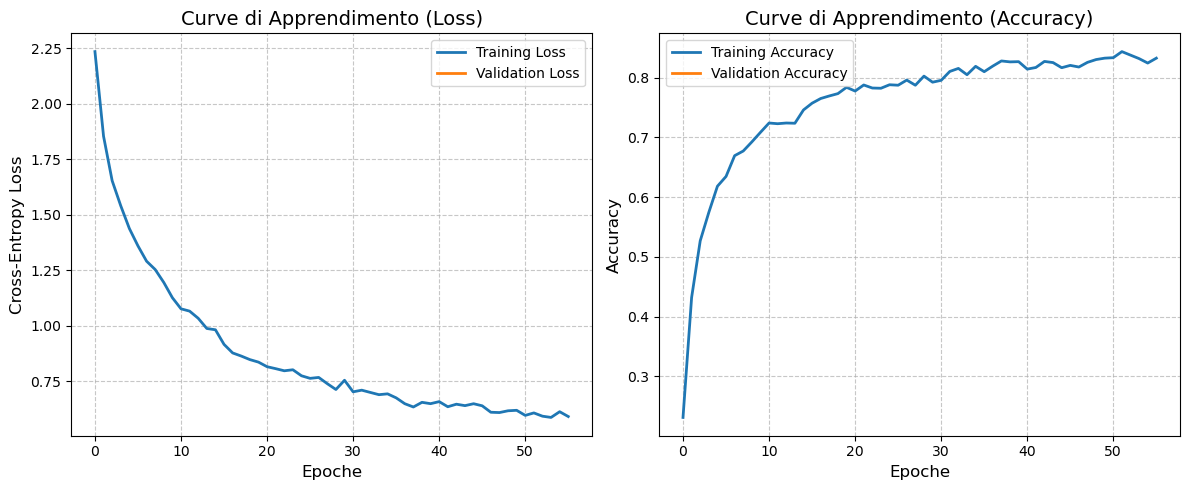

In [ ]:
storia = final_clf.history_

plt.figure(figsize=(12, 5))

# Plot della Loss
plt.subplot(1, 2, 1)
plt.plot(storia['loss'], label='Training Loss', linewidth=2)
plt.plot(storia['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Curve di Apprendimento (Loss)', fontsize=14)
plt.xlabel('Epoche', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot dell'Accuracy
plt.subplot(1, 2, 2)
plt.plot(storia['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(storia['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Curve di Apprendimento (Accuracy)', fontsize=14)
plt.xlabel('Epoche', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


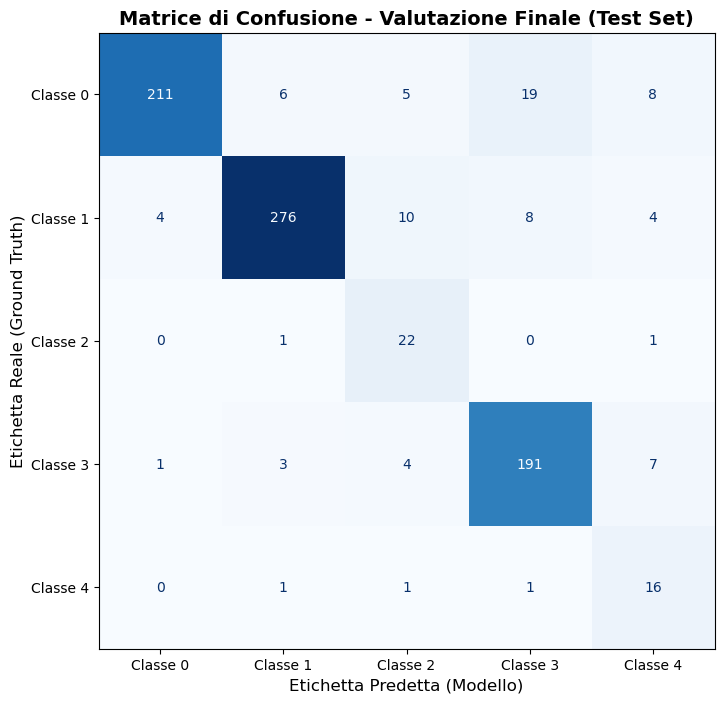

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred_test = final_clf.predict(X_test)


cm = confusion_matrix(y_test, y_pred_test)


fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=["Classe 0", "Classe 1", "Classe 2", "Classe 3", "Classe 4"] # Cambiali coi nomi reali se li hai!
)

disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)
plt.title("Matrice di Confusione - Valutazione Finale (Test Set)", fontsize=14, fontweight='bold')
plt.ylabel('Etichetta Reale (Ground Truth)', fontsize=12)
plt.xlabel('Etichetta Predetta (Modello)', fontsize=12)
plt.show()

Calcolo dell'importanza delle feature in corso...
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


C:\Users\david\AppData\Local\Temp\ipykernel_5576\725379890.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


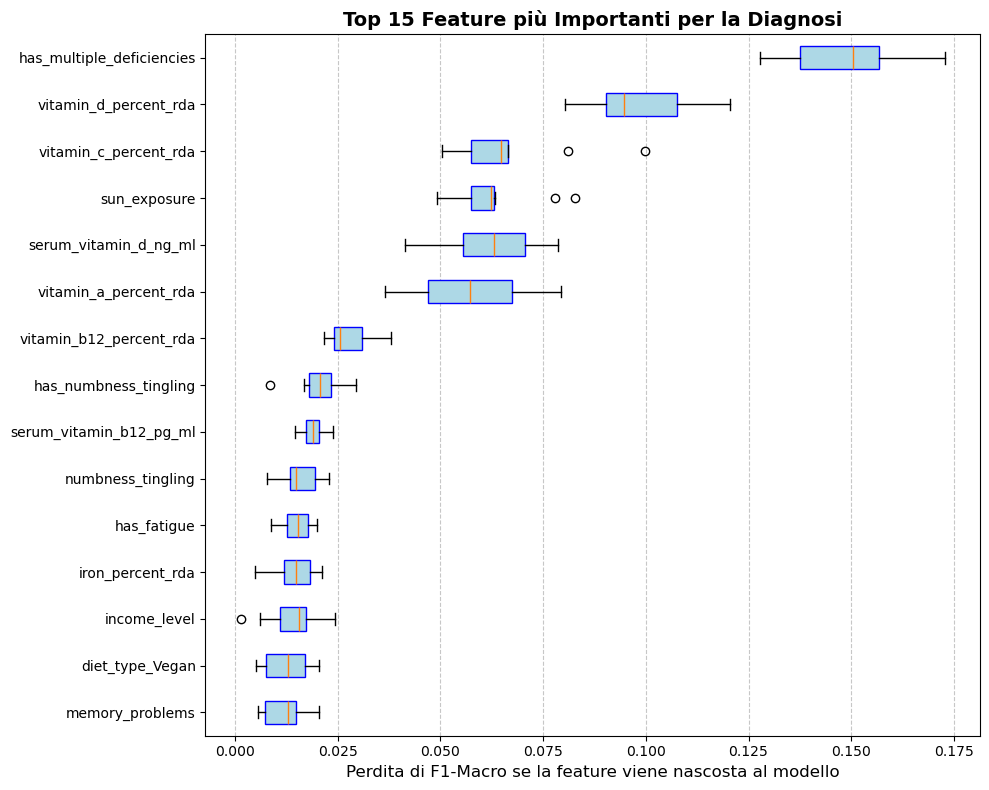

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

print("Calcolo dell'importanza delle feature in corso...")

nomi_feature = X.columns

risultati_importanza = permutation_importance(
    final_clf, X_test, y_test, 
    scoring='f1_macro', 
    n_repeats=10,
    random_state=42, 
    n_jobs=-1
)

# 3. Ordo e prendo le top 15
top_n = 15
indici_ordinati = risultati_importanza.importances_mean.argsort()[-top_n:]

# 4. Assegno i nomi veri alle barre del grafico
etichette_asse_y = np.array(nomi_feature)[indici_ordinati]

# Creo il Boxplot
fig, ax = plt.subplots(figsize=(10, 8))
ax.boxplot(
    risultati_importanza.importances[indici_ordinati].T,
    vert=False, 
    labels=etichette_asse_y, 
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue")
)

plt.title(f"Top {top_n} Feature più Importanti per la Diagnosi", fontsize=14, fontweight='bold')
plt.xlabel("Perdita di F1-Macro se la feature viene nascosta al modello", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score
y_prob = final_clf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
print("AUC OVR macro:", roc_auc)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
AUC OVR macro: 0.9849134487272433


In [ ]:
pip install RuleTree

  Using cached category_encoders-2.8.1-py3-none-any.whl.metadata (7.9 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached progress_table-3.3.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached tempfile312-1.0.1-py3-none-any.whl.metadata (1.7 kB)
  Using cached line_profiler_pycharm-1.2.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl.metadata (9.8 kB)
  Using cached line_profiler-5.0.2-cp310-cp310-win_amd64.whl.metadata (31 kB)
Using cached category_encoders-2.8.1-py3-none-any.whl (85 kB)
Using cached patsy-1.0.2-py2.py3-none-any.whl (233 kB)
Using cached statsmodels-0.14.6-cp310-cp310-win_amd64.whl (9.6 MB)
Using cached line_profiler_pycharm-1.2.0-py3-none-any.whl (4.8 kB)
Using cached line_profiler-5.0.2-cp310-cp310-win_amd64.whl (479 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- -----------------------

In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
trepan_clf = TrepanClassifier(estimator = final_clf, s_min=150, max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred_test, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)




80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━

In [ ]:
attributes = [col for col in X.columns if col != 'disease_diagnosis']
trepan_clf.print_trepan_rules(feature_names=attributes)


  REGOLE GLOBALI ESTRATTE DA TREPAN
REGOLA 1 [Nodo ID: Rll]:
  IF  (symptoms_count <= -0.757) AND (vitamin_d_percent_rda <= -0.670)
  THEN Predizione = 3
  [Fedeltà: 94.12%, Copertura: 0.66%]

REGOLA 2 [Nodo ID: Rlrl]:
  IF  (symptoms_count <= -0.757) AND (vitamin_d_percent_rda > -0.670) AND (vitamin_b12_percent_rda <= -0.720)
  THEN Predizione = 0
  [Fedeltà: 85.71%, Copertura: 0.55%]

REGOLA 3 [Nodo ID: Rlrr]:
  IF  (symptoms_count <= -0.757) AND (vitamin_d_percent_rda > -0.670) AND (vitamin_b12_percent_rda > -0.720)
  THEN Predizione = 1
  [Fedeltà: 99.04%, Copertura: 32.46%]

REGOLA 4 [Nodo ID: Rrlll]:
  IF  (symptoms_count > -0.757) AND (vitamin_d_percent_rda <= -0.552) AND (sun_exposure <= -0.619) AND (vitamin_c_percent_rda <= -1.445)
  THEN Predizione = 4
  [Fedeltà: 83.87%, Copertura: 1.21%]

REGOLA 5 [Nodo ID: Rrllr]:
  IF  (symptoms_count > -0.757) AND (vitamin_d_percent_rda <= -0.552) AND (sun_exposure <= -0.619) AND (vitamin_c_percent_rda > -1.445)
  THEN Predizione = 3
  

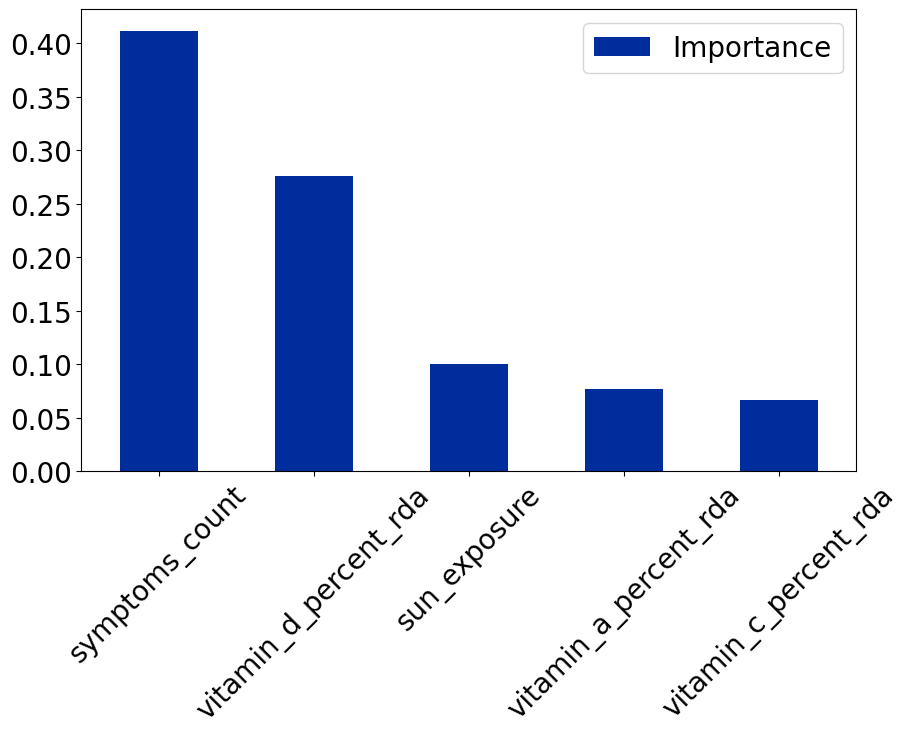

In [ ]:
import pandas as pd
feature_importances = trepan_clf.compute_feature_importances()
feature_names = attributes
if len(feature_importances) < len(feature_names):
    padded_importances = np.zeros(len(feature_names))
    padded_importances[:len(feature_importances)] = feature_importances
    feature_importances = padded_importances



# 2. Ora la creazione del DataFrame Pandas filmerà liscia senza errori
feat_importances = pd.DataFrame(feature_importances, index=feature_names, columns=["Importance"])
feat_importances.sort_values(by='Importance', ascending=False, inplace=True)
feat_importances.head(5).plot(kind='bar', figsize=(10,6), color = '#002d9c')
plt.xticks(fontsize=20, rotation = 45)
plt.yticks(fontsize=20)                       
plt.legend(fontsize=20)  
plt.show()


In [ ]:
# importa la classe direttamente dal file
from RuleTree.tree.TrepanClassifier import TrepanClassifier
from RuleTree.stumps.classification.MofNTrepanStumpClassifier import MofNTrepanStumpClassifier
trepan_clf = TrepanClassifier(estimator = final_clf, s_min=150, base_stumps=[MofNTrepanStumpClassifier()], max_leaf_nodes=25,  prune_useless_leaves=True, random_state=42)
trepan_clf.fit(X_train, y_train)
y_pred_trepan = trepan_clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred_trepan))
print('F1-score %s' % f1_score(y_test, y_pred_trepan, average=None))
print(classification_report(y_test, y_pred_trepan))
fidelty = accuracy_score(y_pred_test, y_pred_trepan)
print("Fidelity of Trepan to the original model:", fidelty)


ModuleNotFoundError: No module named 'RuleTree.tree.TrepanClassifier'